<a href="https://colab.research.google.com/github/jillianb2m/tcc-futebol-analise/blob/main/tcc_ml_futebol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Installs & Imports

## 1.1. Installs

In [ ]:
!pip install pingouin > /dev/null

## 1.2. Imports

In [ ]:
import pandas as pd
import numpy as np
import traceback as tb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from matplotlib.patches import FancyBboxPatch, Patch
from scipy.stats import zscore
import scipy.cluster.hierarchy as sch
import pingouin as pg
import plotly.express as px

# 2. Configuração

In [ ]:
# 5.2. Função main
CONFIG = {
    'POSICAO_ALVO': 'Meia Central',
    'MIN_JOGOS': 5,
    'DATASET_PATH': '/content/tcc-futebol-analise/datasets/processed/brasileirao_opta_final.csv',
    'N_CLUSTERS_MAX': 8,
    'METODO_LINKAGE': 'complete', # 'average'
    'METODO_PADRONIZAR': 'sklearn', # 'zscore'
    'RANDOM_STATE': 100 # 1000
}

# 5.1.1. Inicialização e gerar dataset base
regras_col_agregacao = {
    'rating': 'mean',
    'minutesPlayed': 'sum',
    'totalShots': 'mean',
    'onTargetScoringAttempt': 'mean',
    'bigChanceCreated': 'mean',
    'expectedGoals': 'mean',
    'goals': 'sum',
    'goalAssist': 'sum',
    'totalPass': 'mean',
    'accuratePass': 'mean',
    'keyPass': 'mean',
    'touches': 'mean',
    'possessionLostCtrl': 'mean',
    'totalTackle': 'mean',
    'interceptionWon': 'mean',
    'ballRecovery': 'mean',
    'aerialWon': 'mean',
    'Avg_X': 'mean',
    'Avg_Y': 'mean'
}

# 5.1.1. Inicialização e gerar dataset base
variaveis_esperadas = [
    'rating',
    'minutesPlayed',
    'totalPass',
    'onTargetScoringAttempt',
    'bigChanceCreated',
    'expectedGoals',
    'accuratePass',
    'touches',
    'possessionLostCtrl',
    'ballRecovery',
    'totalShots',
    'goals',
    'totalTackle',
    'interceptionWon',
    'keyPass',
    'goalAssist',
    'aerialWon',
    'Avg_X',
    'Avg_Y'
]

# 5.1.2. Análise Exploratória
mapa_variaveis = {
    'rating': 'Avaliação',
    'minutesPlayed': 'Minutos Jogados',
    'totalPass': 'Total de passes',
    'onTargetScoringAttempt': 'Finalizações no alvo',
    'bigChanceCreated': 'Grandes chances criadas',
    'expectedGoals': 'Gols esperados (xG)',
    'accuratePass': 'Passes certos',
    'touches': 'Toques na bola',
    'possessionLostCtrl': 'Perdas de posse',
    'ballRecovery': 'Recuperações de bola',
    'totalShots': 'Finalizações',
    'goals': 'Gols',
    'totalTackle': 'Desarmes',
    'interceptionWon': 'Interceptações',
    'keyPass': 'Passes-chave',
    'goalAssist': 'Assistências',
    'aerialWon': 'Duelos aéreos ganhos',
    'Avg_X': 'Posição Horizontal',
    'Avg_Y': 'Posição Vertical'
}

# 5.1.2. Análise Exploratória
texto_legenda = (
    "Horizontal (Posição X):\n"
    "• 0 = Lado Esquerdo\n"
    "• 50 = Centro do Campo\n"
    "• 100 = Lado Direito\n\n"
    "Vertical (Posição Y):\n"
    "• 0 = Linha de Ataque\n"
    "• 50 = Linha do Meio Campo\n"
    "• 100 = Linha de Defesa\n\n"
    "Exemplos:\n"
    "• Goleiro: (50, 90)\n"
    "• Zagueiro: (50, 75)\n"
    "• Volante: (50, 60)\n"
    "• Meia: (50, 40)\n"
    "• Atacante: (50, 20)"
)

# 3. Github

## 3.1. Clone

In [ ]:
%run "/content/drive/MyDrive/Colab Notebooks/tcc-clone-repo.py"

<Figure size 640x480 with 0 Axes>

## 3.2. Commit

In [ ]:
#%run "/content/drive/MyDrive/Colab Notebooks/tcc-commit-github.py"

# 4. Coleta e tratamento dos dados

In [ ]:
# %run "/content/tcc-futebol-analise/src/scripts/preparar_base.py"

# 5. Clustering

## 5.1. Classe Clustering

### 5.1.1. Inicialização e gerar dataset base

In [ ]:
class ClusterBrasileirao:
  def __init__(self, dataset_path):
    self.dataframe = pd.read_csv(dataset_path)
    self.dados_cluster = None
    self.variaveis_metricas = None
    self.dados_padronizados = None
    self.scaler = None
    self.centroides = None
    self.df_anova = None

  def gerar_base(self, posicao_alvo=None, min_jogos=5):
    if posicao_alvo:
      df_filtro_alvo = self.dataframe[self.dataframe['Posicao_Real'] == posicao_alvo]
    else:
      df_filtro_alvo = self.dataframe.copy()

    colunas_existentes = [col for col in regras_col_agregacao.keys() if col in df_filtro_alvo.columns]
    agregacoes_filtradas = {k: v for k, v in regras_col_agregacao.items() if k in colunas_existentes}

    df_agregado_alvo = df_filtro_alvo.groupby(['Jogador', 'Time', 'Posicao_Real']).agg(agregacoes_filtradas).reset_index()

    df_alvo = df_agregado_alvo[df_agregado_alvo['minutesPlayed'] >= min_jogos * 90].copy()

    v_metricas = [v for v in variaveis_esperadas if v in df_alvo.columns]

    self.dados_cluster = df_alvo[['Jogador', 'Time', 'Posicao_Real'] + v_metricas].copy()

    self.variaveis_metricas = v_metricas
    dados_metricos = self.dados_cluster[v_metricas].copy()

    return dados_metricos

### 5.1.2. Análise Exploratória

In [ ]:
def explorar_variaveis_dataframe(self):
    print("********* Análise Exploratória *********")

    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)

    print(self.dados_cluster[self.variaveis_metricas].describe().loc[['mean', 'std', 'min', 'max']].T.round(2))
    print("\n")

    fig, axes = plt.subplots(3, 3, figsize=(24, 16))
    fig.suptitle('Distribuição das Variáveis de Desempenho', fontsize=18)

    if 'minutesPlayed' in self.variaveis_metricas:
        dados_melt_1 = pd.melt(self.dados_cluster[['minutesPlayed']])
        dados_melt_1['variable'] = dados_melt_1['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_1, ax=axes[0,0], palette='viridis', legend=False)
        axes[0,0].set_title('Minutos Jogados', fontsize=14)
        axes[0,0].set_ylabel('Minutos', fontsize=12)
        axes[0,0].set_xlabel('', fontsize=12)

    v_nivel_altissimo = ['totalPass', 'accuratePass']
    v_disponiveis_altissimo = [v for v in v_nivel_altissimo if v in self.variaveis_metricas]
    if v_disponiveis_altissimo:
        dados_melt_2 = pd.melt(self.dados_cluster[v_disponiveis_altissimo])
        dados_melt_2['variable'] = dados_melt_2['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_2, ax=axes[0,1], palette='viridis', legend=False)
        axes[0,1].set_title('Passes', fontsize=14)
        axes[0,1].set_ylabel('Valores por Jogo (20-60)', fontsize=12)
        axes[0,1].set_xlabel('', fontsize=12)
        axes[0,1].tick_params(axis='x', rotation=45)

    v_nivel_medio = ['totalTackle', 'keyPass']
    v_disponiveis_medio = [v for v in v_nivel_medio if v in self.variaveis_metricas]
    if v_disponiveis_medio:
        dados_melt_3 = pd.melt(self.dados_cluster[v_disponiveis_medio])
        dados_melt_3['variable'] = dados_melt_3['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_3, ax=axes[0,2], palette='viridis', legend=False)
        axes[0,2].set_title('Desarmes e Assistência (não gol)', fontsize=14)
        axes[0,2].set_ylabel('Valores por Jogo (0-8)', fontsize=12)
        axes[0,2].set_xlabel('', fontsize=12)
        axes[0,2].tick_params(axis='x', rotation=45)

    if 'rating' in self.variaveis_metricas:
        dados_melt_4 = pd.melt(self.dados_cluster[['rating']])
        dados_melt_4['variable'] = dados_melt_4['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_4, ax=axes[1,0], palette='viridis', legend=False)
        axes[1,0].set_title('Desempenho (rating)', fontsize=14)
        axes[1,0].set_ylabel('Avaliação (6-8)', fontsize=12)
        axes[1,0].set_xlabel('', fontsize=12)

    v_assist_shots = ['goalAssist', 'totalShots']
    v_disponiveis_assist = [v for v in v_assist_shots if v in self.variaveis_metricas]
    if v_disponiveis_assist:
        dados_melt_5 = pd.melt(self.dados_cluster[v_disponiveis_assist])
        dados_melt_5['variable'] = dados_melt_5['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_5, ax=axes[1,1], palette='viridis', legend=False)
        axes[1,1].set_title('Assistências e Finalizações', fontsize=14)
        axes[1,1].set_ylabel('Valores por Jogo (0-5)', fontsize=12)
        axes[1,1].set_xlabel('', fontsize=12)
        axes[1,1].tick_params(axis='x', rotation=45)

    if 'goals' in self.variaveis_metricas:
        dados_melt_6 = pd.melt(self.dados_cluster[['goals']])
        dados_melt_6['variable'] = dados_melt_6['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_6, ax=axes[1,2], palette='viridis', legend=False)
        axes[1,2].set_title('Gols', fontsize=14)
        axes[1,2].set_ylabel('Gols por Jogo (0-20)', fontsize=12)
        axes[1,2].set_xlabel('', fontsize=12)

    if 'interceptionWon' in self.variaveis_metricas:
        dados_melt_7 = pd.melt(self.dados_cluster[['interceptionWon']])
        dados_melt_7['variable'] = dados_melt_7['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_7, ax=axes[2,0], palette='viridis', legend=False)
        axes[2,0].set_title('Interceptações', fontsize=14)
        axes[2,0].set_ylabel('Interceptações por Jogo (0-5)', fontsize=12)
        axes[2,0].set_xlabel('', fontsize=12)

    v_posicao = ['Avg_X', 'Avg_Y']
    v_disponiveis_posicao = [v for v in v_posicao if v in self.variaveis_metricas]
    if v_disponiveis_posicao:
        dados_melt_8 = pd.melt(self.dados_cluster[v_disponiveis_posicao])
        dados_melt_8['variable'] = dados_melt_8['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_8, ax=axes[2,1], palette='viridis', legend=False)
        axes[2,1].set_title('Posicionamento em Campo', fontsize=14)
        axes[2,1].set_ylabel('Coordenadas (0-100)', fontsize=12)
        axes[2,1].set_xlabel('', fontsize=12)

    axes[2,2].axis('off')
    axes[2,2].set_title('Legenda - Posicionamento em Campo', fontsize=14)

    rect = FancyBboxPatch((0.1, 0.15), 0.8, 0.7,
                          transform=axes[2,2].transAxes,
                          facecolor='lightblue', alpha=0.9,
                          edgecolor='navy', linewidth=2.0,
                          boxstyle='round,pad=0.5')
    axes[2,2].add_patch(rect)

    axes[2,2].text(0.15, 0.50, texto_legenda, transform=axes[2,2].transAxes,
                  fontsize=14, ha='left', va='center')

    plt.tight_layout()
    plt.savefig('boxplot_analise_exploratoria.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n")

ClusterBrasileirao.explorar_variaveis_dataframe = explorar_variaveis_dataframe

### 5.1.3. Padronização dos Dados (ZScore ou StandardScaler)

In [ ]:
def padronizar_dados(self, metodo='zscore'):

    dados_metricos = self.dados_cluster[self.variaveis_metricas].copy()

    if metodo == 'zscore':
        self.dados_padronizados = dados_metricos.apply(zscore, ddof=1)
        print("Padronização Z-Score aplicada")
    else:
        self.scaler = StandardScaler()
        self.dados_padronizados = pd.DataFrame(self.scaler.fit_transform(dados_metricos),
                                               columns=dados_metricos.columns,
                                               index=dados_metricos.index
                                              )
        print("Padronização StandardScaler aplicada")
    '''
    print("\nMédias após padronização (devem ser ~0):")
    print(self.dados_padronizados.mean())
    print("\nDesvios padrão após padronização (devem ser ~1):")
    print(self.dados_padronizados.std())
    '''
    return self.dados_padronizados

ClusterBrasileirao.padronizar_dados = padronizar_dados

### 5.1.4. Análise quantidade de clusters

In [ ]:
def analisar_clusters(self, max_clusters=8, random_state=100):

    print("Analisando número ideal de clusters\n")

    k_elbow = self.analisar_elbow(max_clusters, random_state)

    k_silhouette = self.analisar_silhouette(max_clusters, random_state)

    print(f"Elbow: {k_elbow}")
    print(f"Silhouette: {k_silhouette}")

    if k_elbow > k_silhouette:
        return k_elbow
    else:
        return k_silhouette

ClusterBrasileirao.analisar_clusters = analisar_clusters

#### 5.1.4.1 Método Elbow

In [ ]:
def analisar_elbow(self, max_clusters=8, random_state=100):

    elbow = []
    K = list(range(1, max_clusters + 1))

    for k in K:
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=10,
            random_state=random_state
        ).fit(self.dados_padronizados)

        elbow.append(kmeans.inertia_)

    plt.figure(figsize=(12, 8), dpi=600)
    plt.plot(K, elbow, marker='o', linewidth=2, markersize=8)
    plt.xlabel('Nº Clusters', fontsize=16)
    plt.ylabel('WCSS', fontsize=16)
    plt.title('Método de Elbow', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('metodo_elbow.png', dpi=300, bbox_inches='tight')
    plt.show()

    points = np.array(list(zip(K, elbow)))

    linha_inicio = points[0]
    linha_fim = points[-1]

    x1, y1 = linha_inicio
    x2, y2 = linha_fim

    distancias = []
    for ponto in points:
        x0, y0 = ponto

        distancia = abs(
            (y2 - y1)*x0 - (x2 - x1)*y0 + x2*y1 - y2*x1
        ) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)

        distancias.append(distancia)

    cotovelo_sugerido = np.argmax(distancias) + 1

    print(f"Nº sugerido de clusters (cotovelo): {cotovelo_sugerido}")
    return cotovelo_sugerido

ClusterBrasileirao.analisar_elbow = analisar_elbow

#### 5.1.4.2. Método Silhueta

In [ ]:
def analisar_silhouette(self, max_clusters=8, random_state=100):

    scores = []
    K = list(range(2, max_clusters + 1))

    for k in K:
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=10,
            random_state=random_state
        )

        labels = kmeans.fit_predict(self.dados_padronizados)
        score = silhouette_score(self.dados_padronizados, labels)
        scores.append(score)

    plt.figure(figsize=(12, 8), dpi=600)
    plt.plot(K, scores, marker='o', linewidth=2, markersize=8)
    plt.xlabel('Nº de Clusters', fontsize=16)
    plt.ylabel('Silhouette Score', fontsize=16)
    plt.title('Análise do Índice de Silhouette', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('metodo_silhouette.png', dpi=300, bbox_inches='tight')
    plt.show()

    melhor_k = K[scores.index(max(scores))]

    print(f"Nº sugerido de clusters (Silhouette): {melhor_k}")
    return melhor_k

ClusterBrasileirao.analisar_silhouette = analisar_silhouette

### 5.1.5. Clustering Hierárquico

In [ ]:
def aplicar_hierarquico(self, n_clusters=3, metodo_linkage='average', metrica_distancia='euclidean'):

      print(f"\n********** Algoritmo Hierárquico ({metodo_linkage} linkage) **********")

      plt.figure(figsize=(16, 8), dpi=600)
      linkage_matrix = sch.linkage(self.dados_padronizados, method=metodo_linkage, metric=metrica_distancia)

      labels_jogadores = [f"{jog}"[:15] for jog in self.dados_cluster['Jogador'].values]
      dendrogram = sch.dendrogram(linkage_matrix, labels=labels_jogadores, color_threshold=6)

      plt.title(f'Dendrograma - {metodo_linkage.title()} Linkage', fontsize=16)
      plt.xlabel('Jogadores', fontsize=16)
      plt.ylabel(f'Distância {metrica_distancia.title()}', fontsize=16)
      plt.axhline(y=12, color='red', linestyle='--')
      plt.xticks(rotation=90)
      plt.tight_layout()
      plt.savefig(f'dendrograma_{metodo_linkage}.png', dpi=300, bbox_inches='tight')
      plt.show()

      cluster_hierarquico = AgglomerativeClustering(n_clusters=n_clusters,
                                                    metric=metrica_distancia,
                                                    linkage=metodo_linkage
                                                    )

      indicadores_cluster = cluster_hierarquico.fit_predict(self.dados_padronizados)
      self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'] = indicadores_cluster
      self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'] = self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'].astype('category')

      coeficientes = [y[1] for y in dendrogram['dcoord']]
      print(f"Coeficientes de aglomeração ({metodo_linkage}): {coeficientes[:5]}...")

      print(f"\nDistribuição dos clusters ({metodo_linkage}):")
      for i in range(n_clusters):
          count = (indicadores_cluster == i).sum()
          percent = (count / len(indicadores_cluster)) * 100
          print(f"Cluster {i}: {count} jogadores ({percent:.1f}%)")

      return indicadores_cluster

ClusterBrasileirao.aplicar_hierarquico = aplicar_hierarquico

### 5.1.6. Clustering K-Means

In [ ]:
def aplicar_kmeans(self, n_clusters=3, init_method='random', random_state=100):
    print(f"\n********** Algoritmo K-MEANS (k={n_clusters}) **********")

    kmeans = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=50,
        random_state=random_state
    ).fit(self.dados_padronizados)

    kmeans_clusters = kmeans.labels_
    self.dados_cluster['cluster_kmeans'] = kmeans_clusters
    self.dados_cluster['cluster_kmeans'] = self.dados_cluster['cluster_kmeans'].astype('category')

    centroides_originais = self.scaler.inverse_transform(kmeans.cluster_centers_)
    self.centroides = pd.DataFrame(centroides_originais, columns=self.variaveis_metricas)

    self.centroides.index.name = 'cluster'

    print("\nCentroides dos clusters:")
    print(self.centroides.round(3))

    centroides_ordenados = self.centroides.sort_values(by='minutesPlayed')

    nomes_clusters = {}

    nomes_clusters[centroides_ordenados.index[0]] = "Baixa participação"
    nomes_clusters[centroides_ordenados.index[1]] = "Média participação"
    nomes_clusters[centroides_ordenados.index[2]] = "Alta participação"

    if len(self.variaveis_metricas) >= 2:
        plt.figure(figsize=(10, 8), dpi=300)

        var1, var2 = self.variaveis_metricas[0], self.variaveis_metricas[1]

        sns.scatterplot(
            data=self.dados_cluster,
            x=var1,
            y=var2,
            hue='cluster_kmeans',
            palette='viridis',
            s=100,
            legend='full'
        )

        centroides_plot = self.centroides[[var1, var2]].copy()

        plt.scatter(
            centroides_plot[var1],
            centroides_plot[var2],
            c='red',
            marker='X',
            s=250,
            label='Centróides'
        )

        for i, row in centroides_plot.iterrows():
            plt.text(
                row[var1] + 0.01,
                row[var2] + 50,
                nomes_clusters.get(i, f'Cluster {i}'),
                fontsize=8,
                #weight='bold',
                color='black'
            )

        handles, labels = plt.gca().get_legend_handles_labels()

        novos_labels = [
            nomes_clusters.get(int(l), l) if l.isdigit() else l
            for l in labels
        ]

        ordem = [
            "Baixa participação",
            "Média participação",
            "Alta participação",
            "Centróides"
        ]

        handles_ordenados = []
        labels_ordenados = []

        for nome in ordem:
            if nome in novos_labels:
                idx = novos_labels.index(nome)
                handles_ordenados.append(handles[idx])
                labels_ordenados.append(nome)

        plt.legend(handles_ordenados, labels_ordenados, title="Clusters")

        plt.title(f'Clusters com base em {mapa_variaveis.get(var1, var1)} e {mapa_variaveis.get(var2, var2)}', fontsize=16)
        plt.xlabel(mapa_variaveis.get(var1, var1), fontsize=14)
        plt.ylabel(mapa_variaveis.get(var2, var2), fontsize=14)

        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.savefig('clusters_kmeans.png', dpi=300, bbox_inches='tight')
        plt.show()

    return kmeans_clusters


ClusterBrasileirao.aplicar_kmeans = aplicar_kmeans

### 5.1.7. Variância ANOVA

In [ ]:
def comparar_clusters_anova(self):
    print("\n=== ANÁLISE DE VARIÂNCIA (ANOVA) ===")

    resultados_anova = []

    for variavel in self.variaveis_metricas:
        print(f"\n--- ANOVA para {variavel} ---")

        resultado = pg.anova(
            dv=variavel,
            between='cluster_kmeans',
            data=self.dados_cluster,
            detailed=True
        )

        print(resultado.round(4))

        linha_cluster = resultado[resultado['Source'] == 'cluster_kmeans']

        if not linha_cluster.empty:
            linha_cluster = linha_cluster.iloc[0]

            f_stat = linha_cluster['F']
            p_value = linha_cluster['p_unc']
            np2 = linha_cluster['np2']

            resultados_anova.append({
                'variavel': variavel,
                'SS': linha_cluster['SS'],
                'DF': linha_cluster['DF'],
                'MS': linha_cluster['MS'],
                'F_stat': f_stat,
                'p_value': p_value,
                'np2': np2,
                'significativo': p_value < 0.05
            })

            print(f"F_stat: {f_stat:.3f}")
            print(f"p_value: {p_value:.4f}")
            print(f"np2: {np2:.3f}")
            print(f"Significativo: {'Sim' if p_value < 0.05 else 'Não'}")

    df_anova = pd.DataFrame(resultados_anova)
    self.df_anova = df_anova

    if not df_anova.empty:
        df_anova = df_anova.sort_values(by='np2', ascending=False)

        mais_discriminante = df_anova.iloc[0]['variavel']
        print(f"\nVariável mais discriminante: {mais_discriminante}")

    return df_anova

ClusterBrasileirao.comparar_clusters_anova = comparar_clusters_anova

In [ ]:
def plot_anova(self, df_anova):

    if df_anova.empty:
        print("DataFrame ANOVA está vazio.")
        return

    df_anova = df_anova.sort_values(by='F_stat', ascending=False)

    labels = df_anova['variavel'].map(mapa_variaveis).fillna(df_anova['variavel'])

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.bar(labels, df_anova['F_stat'], color='steelblue')
    ax1.set_ylabel('F_stat')
    ax1.set_xlabel('Variáveis')
    plt.xticks(rotation=45, ha='right')

    ax2 = ax1.twinx()

    ax2.plot(
        labels,
        df_anova['p_value'],
        color='orange',
        marker='o',
        linewidth=2,
        label='p-value'
    )

    ax2.set_yscale('log')

    ax2.yaxis.set_major_locator(ticker.LogLocator(base=10))
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:.0e}' if y < 0.01 else f'{y:.2f}'))

    ax2.axhline(0.05, color='red', linestyle='--', label='p = 0.05')

    ax2.set_ylabel('p-value', rotation=270, labelpad=15)
    ax2.yaxis.set_label_position("right")

    ax2.legend(loc='center left', bbox_to_anchor=(0.87, 0.5)
)

    plt.title('ANOVA: F_stat e p_value por variável')
    plt.tight_layout()
    plt.show()

ClusterBrasileirao.plot_anova = plot_anova

### 5.1.8. Clusters no gráfico 3D

In [ ]:
def gerar_clusters_3d(self):
    if len(self.variaveis_metricas) >= 3:
        print("\n=== VISUALIZAÇÃO 3D DOS CLUSTERS ===")

        var1, var2, var3 = self.variaveis_metricas[:3]

        fig = px.scatter_3d(
            self.dados_cluster,
            x=var1,
            y=var2,
            z=var3,
            color='cluster_kmeans',
            text=self.dados_cluster['Jogador'],
            title=f'Clusters 3D: {var1} vs {var2} vs {var3}'
        )

        fig.write_html('clusters_3d.html')
        print("Visualização 3D salva como 'clusters_3d.html'")

ClusterBrasileirao.gerar_clusters_3d = gerar_clusters_3d

### 5.1.9. Interpretar perfil dos clusters (jogadores)

In [ ]:
def interpretar_perfis_clusters(self):
    print("\n=== ANÁLISE DE PERFIS DOS CLUSTERS ===")

    n_clusters = self.dados_cluster['cluster_kmeans'].nunique()

    for cluster_id in sorted(self.dados_cluster['cluster_kmeans'].unique()):
        print(f"\n--- CLUSTER {cluster_id} ---")

        dados_cluster = self.dados_cluster[self.dados_cluster['cluster_kmeans'] == cluster_id]

        print(f"Tamanho: {len(dados_cluster)} jogadores")
        print(f"Percentual: {(len(dados_cluster)/len(self.dados_cluster)*100):.1f}%")

        top_jogadores = dados_cluster.nlargest(5, 'rating')[['Jogador', 'Time', 'Posicao_Real', 'rating']]
        print("\nTop 5 jogadores (rating):")
        for _, row in top_jogadores.iterrows():
            print(f"  {row['Jogador']} ({row['Posicao_Real']}) - {row['Time']}: {row['rating']:.1f}")

        print("\nCaracterísticas médias:")
        for var in ['rating', 'minutesPlayed', 'totalPass', 'totalShots', 'goals']:
            if var in dados_cluster.columns:
                media = dados_cluster[var].mean()
                print(f"  {var}: {media:.2f}")

        dist_posicoes = dados_cluster['Posicao_Real'].value_counts()
        print(f"\nPosições principais:")
        for posicao, count in dist_posicoes.head(3).items():
            percent = (count / len(dados_cluster)) * 100
            print(f"  {posicao}: {count} ({percent:.1f}%)")

ClusterBrasileirao.interpretar_perfis_clusters = interpretar_perfis_clusters

### 5.1.10. Identificar reforços

In [ ]:
def identificar_reforcos_elenco(self):
    print("\n=== IDENTIFICAÇÃO DE REFORÇOS POTENCIAIS ===")

    rating_por_cluster = self.dados_cluster.groupby(
        'cluster_kmeans', observed=False
    )['rating'].mean()

    cluster_melhor = rating_por_cluster.idxmax()

    print(f"Cluster com melhor rating médio: {cluster_melhor} (rating: {rating_por_cluster.max():.2f})")

    dados_cluster_alvo = self.dados_cluster.loc[
        self.dados_cluster['cluster_kmeans'] == cluster_melhor
    ].copy()

    metricas_desempenho = ['totalPass', 'totalShots', 'goals', 'totalTackle', 'interceptionWon', 'keyPass']
    metricas_disponiveis = [m for m in metricas_desempenho if m in dados_cluster_alvo.columns]

    if metricas_disponiveis:
        dados_cluster_alvo.loc[:, 'score_desempenho'] = (
            dados_cluster_alvo[metricas_disponiveis].sum(axis=1)
        )

        threshold_desempenho = dados_cluster_alvo['score_desempenho'].quantile(0.75)
        threshold_rating = dados_cluster_alvo['rating'].quantile(0.5)

        reforcos_potenciais = dados_cluster_alvo[
            (dados_cluster_alvo['score_desempenho'] >= threshold_desempenho) &
            (dados_cluster_alvo['rating'] <= threshold_rating)
        ].sort_values('score_desempenho', ascending=False)

        if len(reforcos_potenciais) <= 1:
            reforcos_potenciais = dados_cluster_alvo.sort_values(
                'score_desempenho', ascending=False
            )

        print("\nTop 10 potenciais reforços:")
        for _, row in reforcos_potenciais.head(10).iterrows():
            print(f"{row['Jogador']} ({row['Posicao_Real']}) - {row['Time']}")
            print(f"  Rating: {row['rating']:.1f} | Score: {row['score_desempenho']:.0f}")
            print()

    return reforcos_potenciais if 'reforcos_potenciais' in locals() else None

ClusterBrasileirao.identificar_reforcos_elenco = identificar_reforcos_elenco

## 5.2. Função main

Padronização StandardScaler aplicada


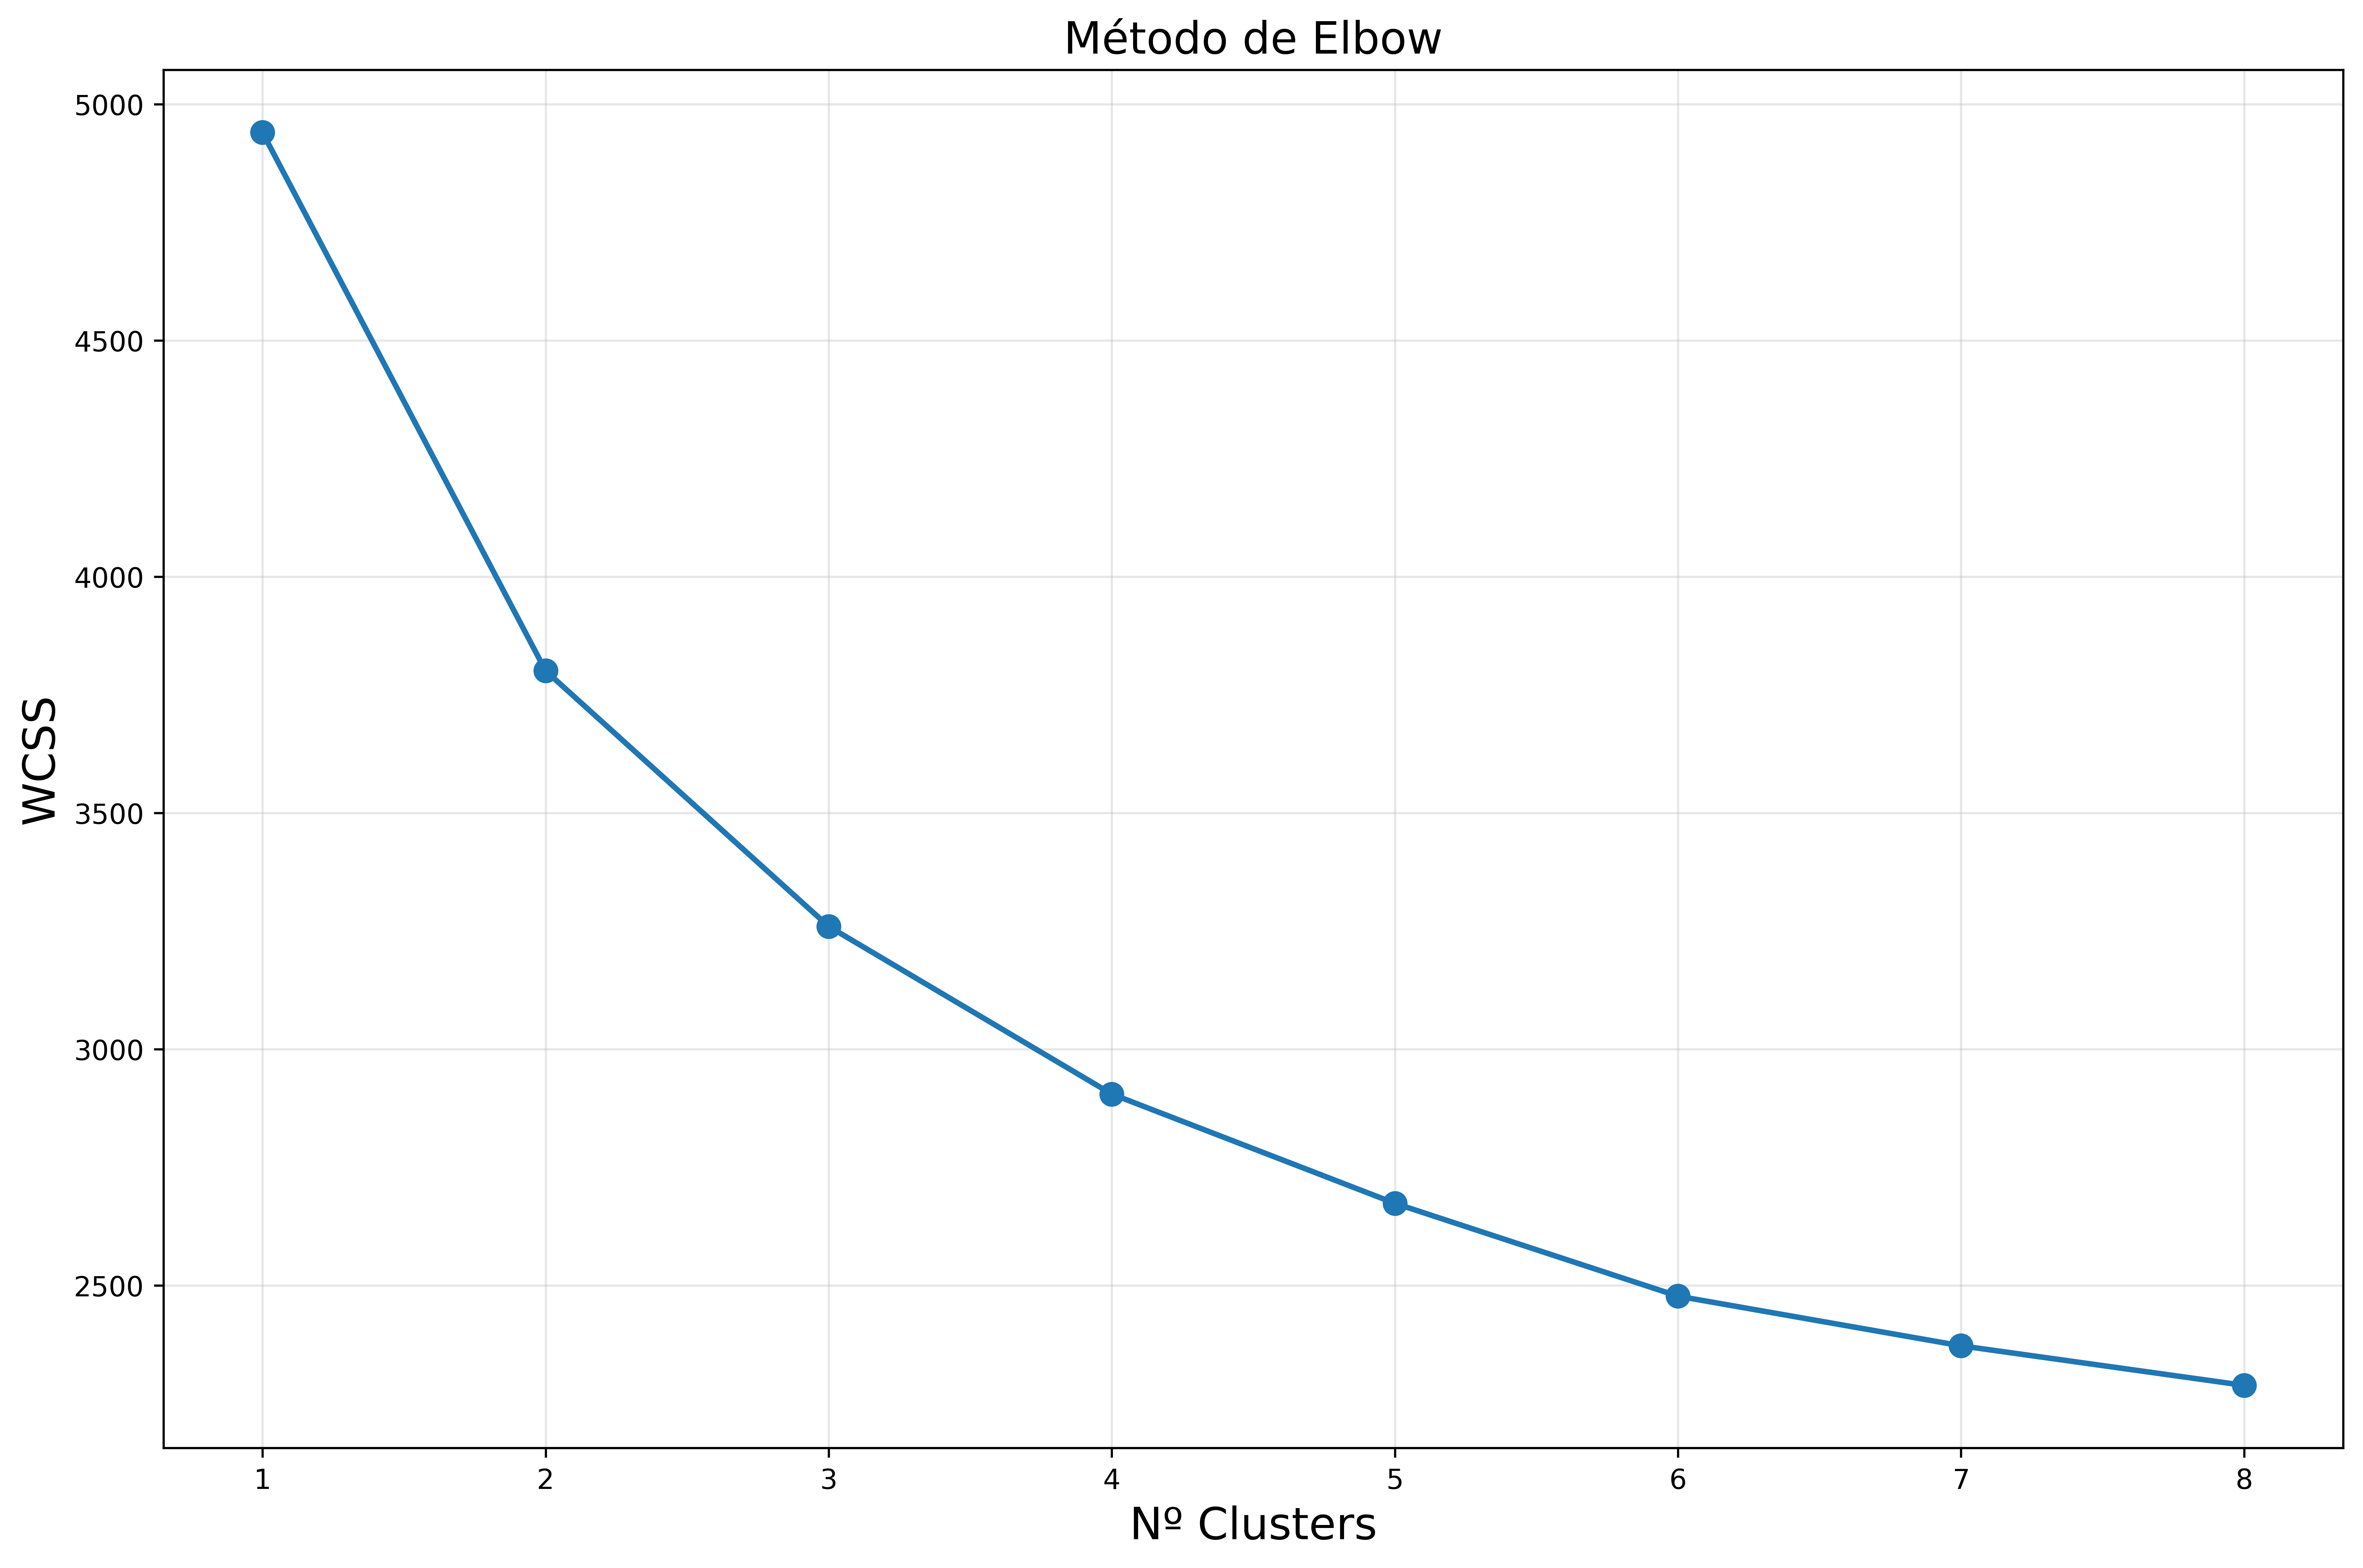

Nº sugerido de clusters (cotovelo): 3

********** Algoritmo K-MEANS (k=3) **********

Centroides dos clusters:
         rating  minutesPlayed  totalPass  onTargetScoringAttempt  \
cluster                                                             
0         6.777        785.609     14.690                   0.467   
1         7.097       2226.382     21.988                   0.830   
2         6.993       1040.864     34.286                   0.362   

         bigChanceCreated  expectedGoals  accuratePass  touches  \
cluster                                                           
0                   0.093          0.146        11.406   24.794   
1                   0.185          0.270        17.204   35.755   
2                   0.153          0.093        29.389   47.501   

         possessionLostCtrl  ballRecovery  totalShots  goals  totalTackle  \
cluster                                                                     
0                     7.150         1.881       1.221

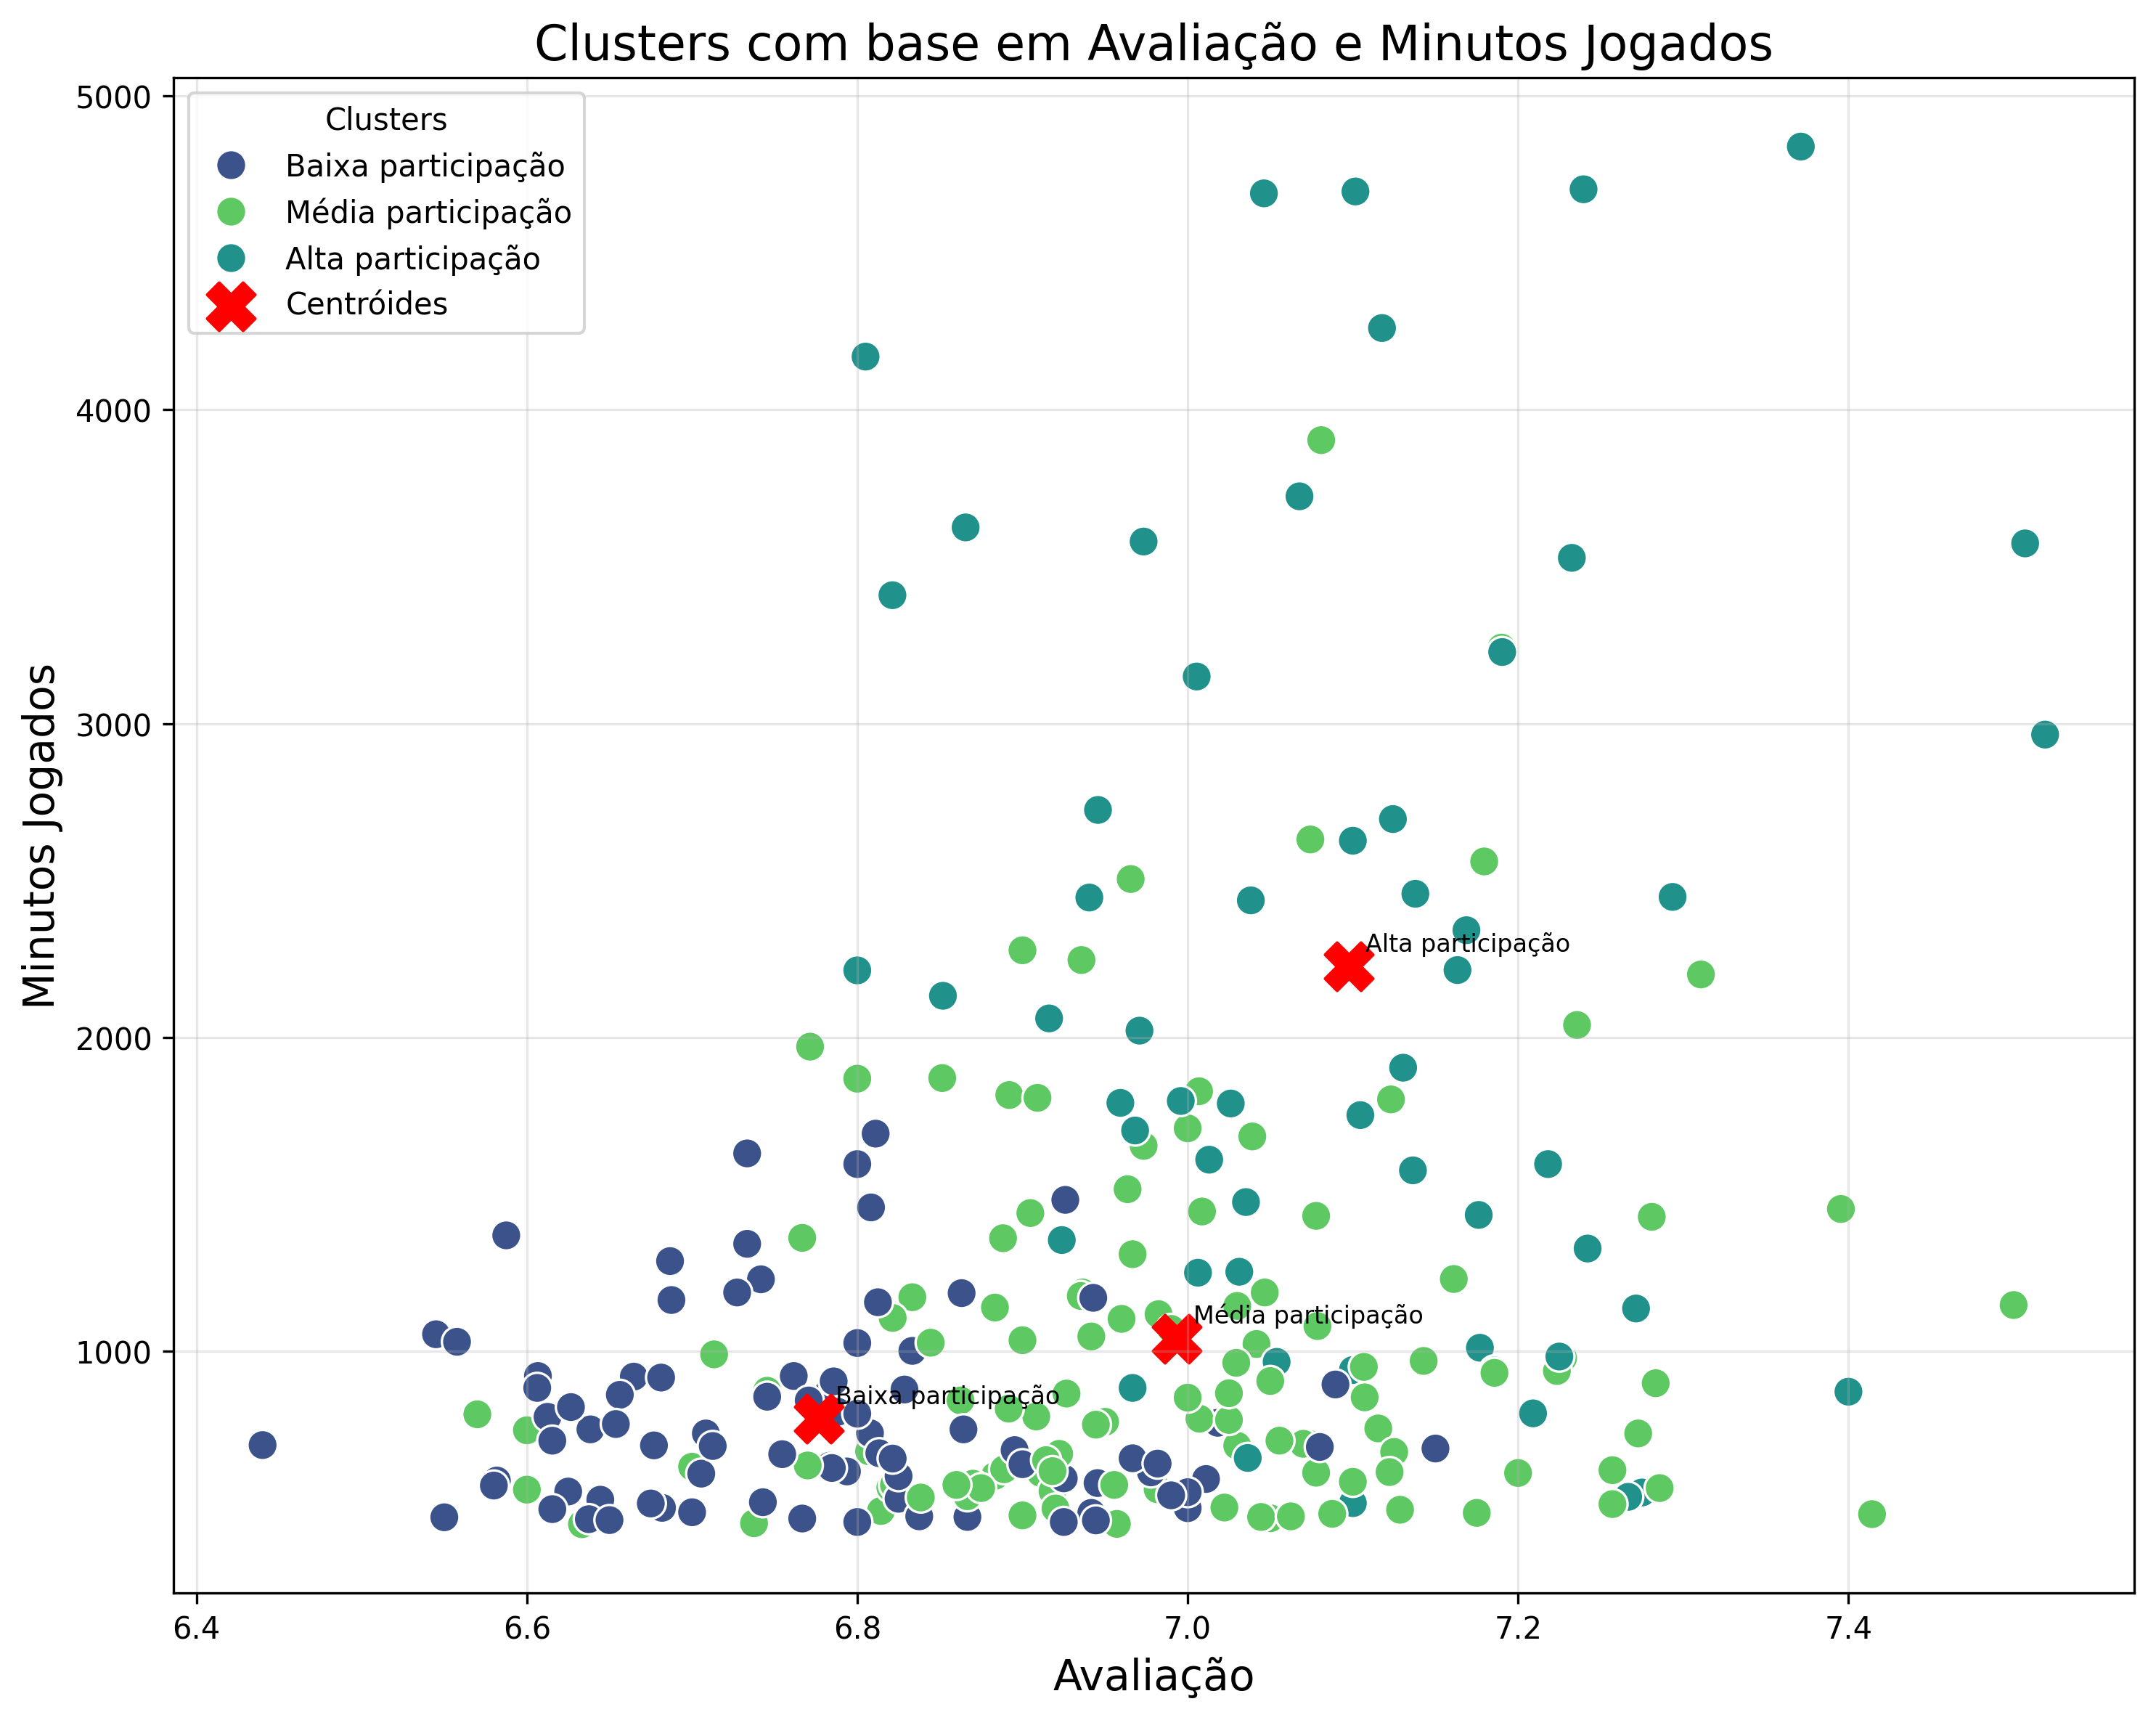


=== ANÁLISE DE VARIÂNCIA (ANOVA) ===

--- ANOVA para rating ---
           Source      SS   DF      MS        F  p_unc     np2
0  cluster_kmeans  4.0138    2  2.0069  78.5921    0.0  0.3795
1          Within  6.5626  257  0.0255      NaN    NaN     NaN
F_stat: 78.592
p_value: 0.0000
np2: 0.380
Significativo: Sim

--- ANOVA para minutesPlayed ---
           Source            SS   DF            MS        F  p_unc     np2
0  cluster_kmeans  7.585804e+07    2  3.792902e+07  74.6987    0.0  0.3676
1          Within  1.304944e+08  257  5.077604e+05      NaN    NaN     NaN
F_stat: 74.699
p_value: 0.0000
np2: 0.368
Significativo: Sim

--- ANOVA para totalPass ---
           Source          SS   DF         MS         F  p_unc     np2
0  cluster_kmeans  19917.1497    2  9958.5748  120.7442    0.0  0.4844
1          Within  21196.4885  257    82.4766       NaN    NaN     NaN
F_stat: 120.744
p_value: 0.0000
np2: 0.484
Significativo: Sim

--- ANOVA para onTargetScoringAttempt ---
           Source

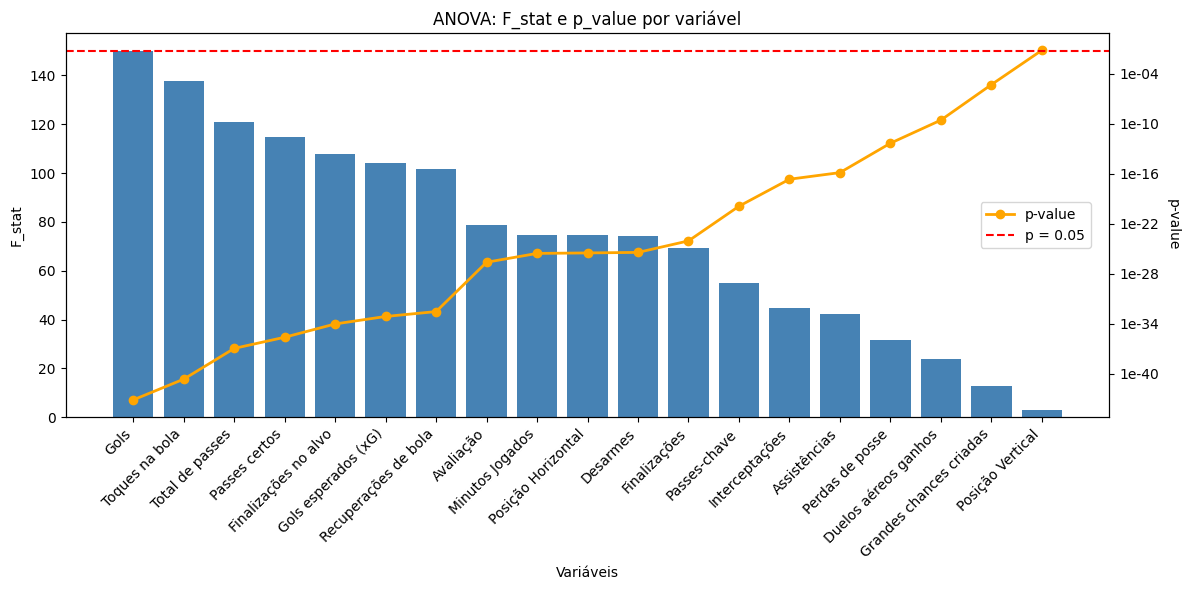

In [ ]:
def main(pos_alvo=CONFIG['POSICAO_ALVO'], min_jogos=CONFIG['MIN_JOGOS']):

  resultado_final = ClusterBrasileirao(CONFIG['DATASET_PATH'])

  try:
    dados_metricos_result = resultado_final.gerar_base(pos_alvo, min_jogos)
  except Exception as e:
    print('Erro ao gerar dados métricos: ' + tb.format_exc())

  # resultado_final.explorar_variaveis_dataframe()

  dados_padronizados = resultado_final.padronizar_dados(metodo=CONFIG['METODO_PADRONIZAR'])

  """
  k_ideal = resultado_final.analisar_clusters(max_clusters=CONFIG['N_CLUSTERS_MAX'], random_state=CONFIG['RANDOM_STATE'])

  for i in range(k_ideal, CONFIG['N_CLUSTERS_MAX']):
    resultado_final.aplicar_hierarquico(n_clusters=i, metodo_linkage=CONFIG['METODO_LINKAGE'])

    resultado_final.aplicar_kmeans(n_clusters=i)
  """

  k_ideal = resultado_final.analisar_elbow(max_clusters=CONFIG['N_CLUSTERS_MAX'], random_state=CONFIG['RANDOM_STATE'])

  #resultado_final.aplicar_hierarquico(n_clusters=k_ideal, metodo_linkage=CONFIG['METODO_LINKAGE'])
  resultado_final.aplicar_kmeans(n_clusters=k_ideal)


  resultado_final.comparar_clusters_anova()
  resultado_final.plot_anova(resultado_final.df_anova)

  """
  resultado_final.gerar_clusters_3d()
  resultado_final.interpretar_perfis_clusters()
  resultado_final.identificar_reforcos_elenco()

  return dados_metricos_result
  """
if __name__ == "__main__":
    dados_metricos = main()